1ª Etapa: exploração e limpeza dos dados com Pandas
A primeira tarefa de qualquer analista é entender a qualidade dos dados. Antes de carregar tudo em um banco de dados, use o Pandas para uma análise exploratória. A diretoria quer um resumo rápido do desempenho de vendas no trimestre.

Pergunta-chave: "Como foi nosso desempenho de vendas no primeiro trimestre e quais são as categorias de maior destaque?"

Sua missão:

Carregue o arquivo vendas.csv em um DataFrame.
Desafio de limpeza: Verifique a existência de dados ausentes (NaN) ou duplicados. O arquivo pode conter algumas linhas com valor_venda ou quantidade nulos. Decida a melhor estratégia: removê-los ou preenchê-los? Justifique sua escolha.

Calcule o faturamento total (valor_venda * quantidade) para cada registro e crie uma nova coluna chamada faturamento.

Agrupe os dados por mês para visualizar a tendência de faturamento.
Agrupe os dados por categoria para entender a distribuição do faturamento.
Use o Matplotlib para criar duas visualizações simples:
- Um gráfico de linha mostrando o faturamento total por mês.
- Um gráfico de barras mostrando o faturamento total por categoria.


Ferramentas: Pandas, Matplotlib.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dados = pd.read_csv('/content/drive/MyDrive/Carreira Alura: Análise de Dados/Checkpoint - nível 1/vendas.csv')
dados.head()

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade
0,1,2023-02-07,109,8,Livro: A Guerra dos Tronos,Livros,2677.12,2
1,2,2023-01-11,139,7,Headset Surround 7.1,Áudio,1210.10,1
2,3,2023-02-16,104,17,Mousepad Gamer XXL,Periféricos,2393.06,2
3,4,2023-03-20,145,17,Mousepad Gamer XXL,Periféricos,3925.92,3
4,5,2023-02-16,134,16,Memória RAM 16GB DDR5,Componentes,4702.89,1


In [8]:
dados.describe()

,id_venda,id_cliente,id_produto,valor_venda,quantidade
count,120.000000,120.00000,120.000000,120.000000,120.000000
mean,60.500000,124.15000,9.650000,2742.479750,2.425000
std,34.785054,12.73957,5.376028,1399.236646,1.149808
min,1.000000,101.00000,1.000000,55.020000,1.000000
25%,30.750000,114.00000,6.000000,1543.417500,1.000000
50%,60.500000,124.00000,10.000000,2812.445000,2.000000
75%,90.250000,134.00000,13.000000,3922.972500,3.000000
max,120.000000,149.00000,19.000000,4976.810000,4.000000


In [11]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venda     120 non-null    int64  
 1   data_venda   120 non-null    object 
 2   id_cliente   120 non-null    int64  
 3   id_produto   120 non-null    int64  
 4   produto      120 non-null    object 
 5   categoria    120 non-null    object 
 6   valor_venda  120 non-null    float64
 7   quantidade   120 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 7.6+ KB


Verificando a existência de dados nulos, dados ausentes(NaN) e dados duplicados.

In [4]:
#Verificando dados ausentes
dados.isna().sum()

,0
id_venda,0
data_venda,0
id_cliente,0
id_produto,0
produto,0
categoria,0
valor_venda,0
quantidade,0


In [7]:
#Verificando dados nulos
dados.isnull().sum()

,0
id_venda,0
data_venda,0
id_cliente,0
id_produto,0
produto,0
categoria,0
valor_venda,0
quantidade,0


In [6]:
#Verificando dados duplicados
dados.duplicated().sum()

np.int64(0)

Após a verificação, não foi encontrado nenhum dado ausente(NaN), nenhum dado nulo além nenhum dado duplicado, os quais se existissem seriam excluídos.

Podemos seguir para o próximo passo: Criar a coluna de 'faturamento', multiplicando os dados das colunas 'valor_venda' e 'quantidade'.

In [12]:
dados['faturamento'] = dados['valor_venda'] * dados['quantidade']
dados

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade,faturamento
0,1,2023-02-07,109,8,Livro: A Guerra dos Tronos,Livros,2677.12,2,5354.24
1,2,2023-01-11,139,7,Headset Surround 7.1,Áudio,1210.10,1,1210.10
2,3,2023-02-16,104,17,Mousepad Gamer XXL,Periféricos,2393.06,2,4786.12
3,4,2023-03-20,145,17,Mousepad Gamer XXL,Periféricos,3925.92,3,11777.76
4,5,2023-02-16,134,16,Memória RAM 16GB DDR5,Componentes,4702.89,1,4702.89
...,...,...,...,...,...,...,...,...,...
115,116,2023-01-26,143,19,Livro: Duna,Livros,991.78,1,991.78
116,117,2023-01-07,103,10,Mesa Digitalizadora,Periféricos,4726.90,2,9453.80
117,118,2023-03-07,101,11,Luminária de Mesa LED,Decoração,4242.74,2,8485.48
118,119,2023-01-24,128,9,Webcam 4K,Periféricos,800.63,3,2401.89


Próximo passo: Agrupe os dados por mês para visualizar a tendência de faturamento.

Primeiro teremos que passar a coluna 'data_venda' para o tipo 'datetime' para que possamos agrupar pelos meses.

In [26]:
#Transformação da coluna 'data_venda' para 'date_time'
dados['data_venda'] = pd.to_datetime(dados['data_venda'], format = '%Y-%m-%d')
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venda     120 non-null    int64         
 1   data_venda   120 non-null    datetime64[ns]
 2   id_cliente   120 non-null    int64         
 3   id_produto   120 non-null    int64         
 4   produto      120 non-null    object        
 5   categoria    120 non-null    object        
 6   valor_venda  120 non-null    float64       
 7   quantidade   120 non-null    int64         
 8   faturamento  120 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 8.6+ KB


Após realizado a transformação dos dados poderemos realizar o agrupamento do faturamento pelos meses disponíveis.

In [27]:
#Calculado o faturamento pelos meses
faturamento_mensal = dados.groupby(dados['data_venda'].dt.month)['faturamento'].sum().sort_values(ascending = False)
faturamento_mensal

,faturamento
data_venda,
3,293842.93
2,282351.34
1,234634.61


Com isso, podemos seguir para o próximo passo:

Agrupe os dados por categoria para entender a distribuição do faturamento.

In [20]:
#Agrupando os dados por Categorias
agrupar_categoria = dados.groupby(dados['categoria'])['faturamento'].sum().sort_values(ascending = False)
agrupar_categoria

,faturamento
categoria,
Periféricos,307921.82
Livros,140285.75
Eletrônicos,124973.54
Decoração,109156.43
Colecionáveis,55658.46
Componentes,35468.07
Áudio,29281.47
Móveis,8083.34


Com isso, podemos verificar que a categoria mais rentável é a de Periféricos, isso ficará mais visível no gráfico que será feito abaixo.

Seguindo para o próximo passo, temos:

- Um gráfico de linha mostrando o faturamento total por mês.
- Um gráfico de barras mostrando o faturamento total por categoria.

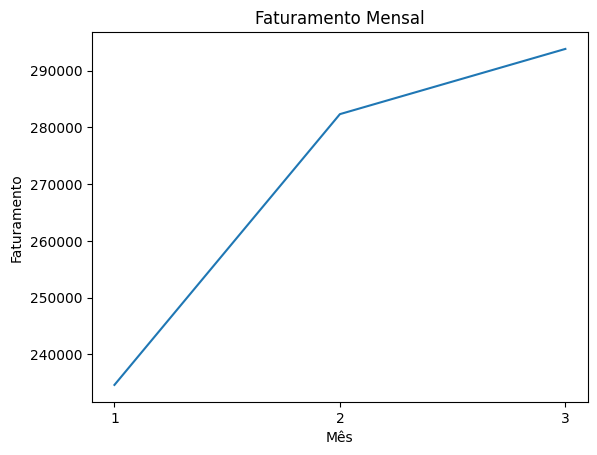

In [31]:
import matplotlib.ticker as mticker

plt.plot(faturamento_mensal, label = 'Faturamento')
plt.title('Faturamento Mensal')
plt.xlabel('Mês')
plt.ylabel('Faturamento')

# Obtém o eixo atual
ax = plt.gca()
# Define o localizador principal do eixo x para mostrar apenas ticks inteiros
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.show()

A utilização da da biblioteca 'matplotlib.ticker' foi feita para ajustar os xticks, uma vez que o gráfico estava apresentando os meses como: '1.00 1.25 1.50...3.0', e não da forma correta.

Gráfico de barras por Categoria:

Text(0.5, 0, 'Categorias')

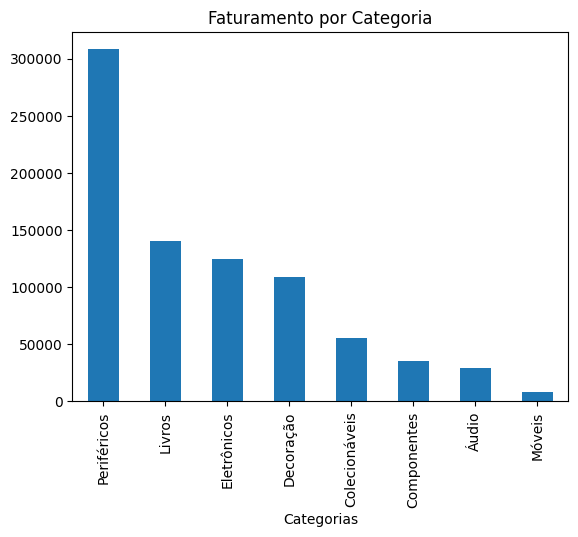

In [43]:
agrupar_categoria.plot(kind = 'bar')
plt.title('Faturamento por Categoria')
plt.xlabel('Categorias')

Desafio 1, finalizado.
Com isso, podemos seguir para o desafio 2, que será feito no MySQL.